In [1]:
import sys
from pathlib import Path
sys.path.append("/export/home/mklockow/boa")

# autoreload magic
%load_ext autoreload
%autoreload 2

import os
os.environ["PROJECT_ROOT"] = "/export/home/mklockow/boa"

# Monkey patch the HydraConfig.get method to avoid the error
from hydra.core.hydra_config import HydraConfig

# Store the original method before patching
_original_get = HydraConfig.get

@classmethod 
def patched_get(cls):
    try:
        instance = cls.instance()
        if instance.cfg is None:
            raise ValueError("HydraConfig was not set")
        return instance.cfg.hydra
    except ValueError:
        # Return a minimal mock config when HydraConfig is not set
        from omegaconf import DictConfig
        mock_config = DictConfig({
            "job": {
                "override_dirname": "",
                "num": "0"
            },
            "runtime": {
                "output_dir": "/tmp/hydra_fallback"
            },
            "sweep": {
                "dir": "/tmp/hydra_sweep"
            }
        })
        return mock_config

# Apply the monkey patch
HydraConfig.get = patched_get

device = "cuda:2"

In [2]:
# instantiate dataset instead using hydra
from hydra import compose, initialize
from hydra.utils import instantiate
from hydra.core.global_hydra import GlobalHydra


GlobalHydra.instance().clear()
initialize(config_path="../configs", job_name="test_app")
cfg = compose(config_name="train", overrides=["data.datamodule.batch_size.train=1", "experiment=qm9_vasp", "model.use_radial_correction=False",
                                               "data.datamodule.n_probe.train=1000",
                                               "data.datamodule.n_probe.val=1000",
                                               "data.datamodule.n_probe.test=1000",
                                               "data.datamodule.batch_size.val=1",
                                               "data.datamodule.batch_size.test=1",])
print(cfg)
datamodule = instantiate(cfg.data.datamodule, _recursive_=False)
print(datamodule)
datamodule.setup("fit")
print(datamodule)
train_loader = datamodule.train_dataloader()
valid_loader = datamodule.val_dataloader()
test_loader = datamodule.test_dataloader()

GlobalHydra.instance().clear()
initialize(config_path="../configs", job_name="test_app")
cfg = compose(config_name="train", overrides=["data.datamodule.batch_size.train=1", "experiment=qm9_vasp", "model.use_radial_correction=False",
                                               "data/datamodule/dataset/transform=random_rotate_qm9",
                                               "data.datamodule.n_probe.train=1000",
                                               "data.datamodule.n_probe.val=1000",
                                               "data.datamodule.n_probe.test=1000",
                                               "data.datamodule.batch_size.val=1",
                                               "data.datamodule.batch_size.test=1",])
print(cfg)
random_rotate_datamodule = instantiate(cfg.data.datamodule, _recursive_=False)
print(random_rotate_datamodule)
random_rotate_datamodule.setup("fit")
print(random_rotate_datamodule)
random_rotate_train_loader = random_rotate_datamodule.train_dataloader()
random_rotate_valid_loader = random_rotate_datamodule.val_dataloader()
random_rotate_test_loader = random_rotate_datamodule.test_dataloader()

/tmp/ipykernel_630659/3580543256.py:8: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="test_app")
/export/home/mklockow/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)
/export/home/mklockow/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration in

{'data': {'datamodule': {'split_file': '${paths.data_dir}/${data.dataset_name}/datasplits.json', 'dataloader_kwargs': {'follow_batch': ['coeffs', 'atomic_numbers'], 'list_keys': []}, 'n_probe': {'val': 1000, 'test': 1000, 'train': 1000}, 'num_workers': {'train': 16, 'val': 16, 'test': 16}, 'dataset': {'transform': {'_target_': 'boa.data.transforms.MasterTransform', 'transforms': [{'_target_': 'boa.data.transforms.SampleProbe', 'n_probe': '${data.datamodule.n_probe.train}'}, {'_target_': 'boa.data.transforms.ConvertToOFData', 'basis_info': '${data.basis_info}'}, {'_target_': 'boa.data.transforms.ToTorch'}, {'_target_': 'boa.data.transforms.AddMessagePassingMatrix', 'basis_info': '${data.basis_info}', 'type': 'overlap', 'remove_diagonal': False}, {'_target_': 'boa.data.transforms.AddRadiusEdgeIndex', 'radius': 6.0, 'name': 'message_edge_index'}, {'_target_': 'boa.data.transforms.AddEdgeMatrices', 'basis_info': '${data.basis_info}', 'edge_name': '${..4.name}', 'name': 'message_edge_matric

/tmp/ipykernel_630659/3580543256.py:25: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="test_app")
/export/home/mklockow/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)
/export/home/mklockow/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration i

{'data': {'datamodule': {'split_file': '${paths.data_dir}/${data.dataset_name}/datasplits.json', 'dataloader_kwargs': {'follow_batch': ['coeffs', 'atomic_numbers'], 'list_keys': []}, 'n_probe': {'val': 1000, 'test': 1000, 'train': 1000}, 'num_workers': {'train': 16, 'val': 16, 'test': 16}, 'dataset': {'transform': {'_target_': 'boa.data.transforms.MasterTransform', 'transforms': [{'_target_': 'boa.data.transforms.SampleProbe', 'n_probe': '${data.datamodule.n_probe.train}'}, {'_target_': 'boa.data.transforms.ConvertToOFData', 'basis_info': '${data.basis_info}'}, {'_target_': 'boa.data.transforms.ToTorch'}, {'_target_': 'boa.data.transforms.RandomRotateMol'}, {'_target_': 'boa.data.transforms.AddMessagePassingMatrix', 'basis_info': '${data.basis_info}', 'type': 'overlap', 'remove_diagonal': False}, {'_target_': 'boa.data.transforms.AddRadiusEdgeIndex', 'radius': 6.0, 'name': 'message_edge_index'}, {'_target_': 'boa.data.transforms.AddEdgeMatrices', 'basis_info': '${data.basis_info}', 'ed

In [3]:
from pytorch_lightning import LightningModule

from boa.model.module import ChgLightningModule


# metadata = getattr(datamodule, "metadata", None)
# model = instantiate(
#     cfg.model,
#     train=cfg,
#     _recursive_=False,
#     metadata=metadata,
# )

# model = model.to(device)
# model.eval()

model = ChgLightningModule.load_from_checkpoint("/export/scratch/mklockow/boa/models/train/runs/453_qm9_small_qm9_vasp_small_noradcor__seed-2/last.ckpt")
model = model.to(device)
model.eval()

Unique atom types: [1 6 7 8 9]


/export/home/mklockow/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+2x2e+1x3o -> 7x0e+4x1o+2x2e+1x3o | 70 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (7): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (8): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
            (9): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
          )

ChgLightningModule(
  (gto_dict): ModuleDict(
    (1): GTOs(Lmax=3, n_orbitals=14, n_contracted=14.0, outdim=36)
    (6): GTOs(Lmax=4, n_orbitals=31, n_contracted=31.0, outdim=83)
    (7): GTOs(Lmax=4, n_orbitals=31, n_contracted=31.0, outdim=83)
    (8): GTOs(Lmax=4, n_orbitals=32, n_contracted=32.0, outdim=86)
    (9): GTOs(Lmax=4, n_orbitals=32, n_contracted=32.0, outdim=86)
  )
  (model): BOA(
    (boa_stack): BoaBlockStack(
      (blocks): ModuleList(
        (0-3): 4 x BoaBlock(
          (linear0): StableLinearNodeOperator(
            (stable_linear_node_operators): ModuleDict(
              (1): StableLinearNodeOperatorAtom(
                (linear1): Linear(7x0e+4x1o+2x2e+1x3o -> 7x0e+4x1o+2x2e+1x3o | 70 weights)
              )
              (6): StableLinearNodeOperatorAtom(
                (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
              )
              (7): StableLinearNodeOperatorAtom(
                (linear1): Linear

In [4]:
import torch
batch = next(iter(valid_loader))
batch = batch.to(device)
loss, pred, chg_labels, coeffs = model(batch)

# rotated_batch = batch.clone()
# # get random rotation matrix
# import torch
# import e3nn
# R = e3nn.o3.rand_matrix()
# R = R.to(device)
# print(R@R.T)  # should be close to identity

rotated_batch = next(iter(random_rotate_valid_loader))
rotated_batch = rotated_batch.to(device)
rotated_batch.chg_labels = batch.chg_labels
rotated_batch.probe_coords = batch.probe_coords @ rotated_batch.rot_mat.T
rotated_loss, rotated_pred, rotated_chg_labels, rotated_coeffs = model(rotated_batch)
# print(batch)

[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OFData without specifying the representation. The key rot_mat will not transform.
[rank: 0] Adding attribute rot_mat to OF

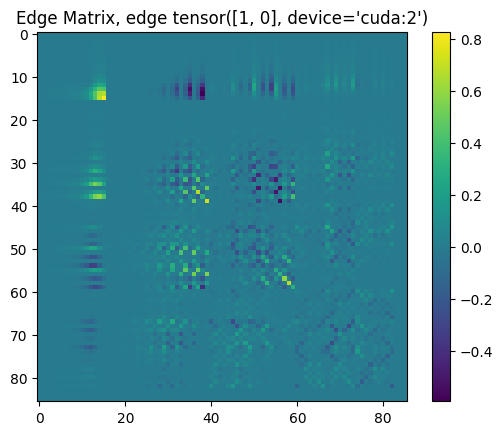

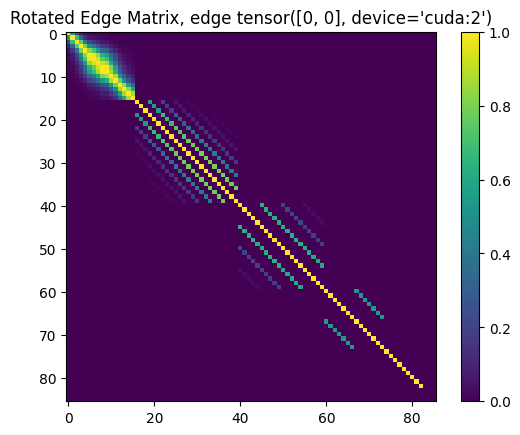

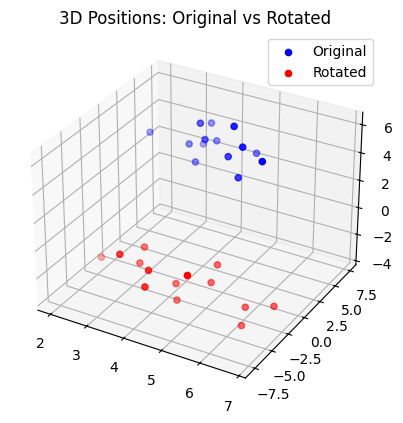

In [5]:
# imshow the first edge_matrix in the batch
import matplotlib.pyplot as plt
import numpy as np
edge_matrix = batch.edge_matrices[0].cpu().numpy()
plt.imshow(edge_matrix, cmap='viridis')
plt.colorbar()
plt.title(f"Edge Matrix, edge {batch.edge_index[:,0]}")
plt.show()

edge_matrix_rotated = rotated_batch.edge_matrices[0].cpu().numpy()
plt.imshow(edge_matrix_rotated, cmap='viridis')
plt.colorbar()
plt.title(f"Rotated Edge Matrix, edge {rotated_batch.edge_index[:,0]}")
plt.show()

# 3d plot the original and rotated positions
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(batch.pos[:,0].cpu(), batch.pos[:,1].cpu(), batch.pos[:,2].cpu(), c='b', label='Original')
ax.scatter(rotated_batch.pos[:,0].cpu(), rotated_batch.pos[:,1].cpu(), rotated_batch.pos[:,2].cpu(), c='r', label='Rotated')
ax.set_title('3D Positions: Original vs Rotated')
ax.legend()
plt.show()

In [6]:
# emb = model.model.node_embedding(batch.atomic_numbers, batch.coeff_ind_to_node_ind)
# print(emb.shape)
# emb_edge = model.model.edge_embedding(batch)[0]
# # print emb_edge for first self loop
# self_loop_mask = batch.edge_index[0] == batch.edge_index[1]
# emb_edge = emb_edge[self_loop_mask]
# print(emb_edge.shape)
# print(emb_edge[0, : , 0])

In [7]:
print("loss:", loss.item(), rotated_loss.item())
print("error: ", (pred - rotated_pred).abs().sum() / pred.abs().sum())
print((pred - rotated_pred).abs().sum(), pred.abs().sum())

loss: 0.0028845807537436485 0.0028848915826529264
error:  tensor(1.8323e-06, device='cuda:2', grad_fn=<DivBackward0>)
tensor(0.0001, device='cuda:2', grad_fn=<SumBackward0>) tensor(70.9031, device='cuda:2', grad_fn=<SumBackward0>)


In [8]:
# Create enhanced PyVista visualization with density values
import pyvista as pv
from pyvista import themes
import numpy as np

# Restart with fresh data to avoid CUDA errors
pv.set_jupyter_backend('html')

# Get the data we need - convert to CPU first to avoid CUDA issues
probe_coords_np = batch.probe_coords.cpu().numpy()
rotated_probe_coords_np = rotated_batch.probe_coords.cpu().numpy()
pred_np = pred.detach().cpu().numpy()
rotated_pred_np = rotated_pred.detach().cpu().numpy()
atomic_pos_np = batch.pos.cpu().numpy()
rotated_atomic_pos_np = rotated_batch.pos.cpu().numpy()

print(f"Data ranges:")
print(f"Original predictions: [{pred_np.min():.6f}, {pred_np.max():.6f}]")
print(f"Rotated predictions: [{rotated_pred_np.min():.6f}, {rotated_pred_np.max():.6f}]")

# Filter significant density points (above threshold for better visualization)
density_threshold = 0.01  # Adjust this to show more/fewer points
significant_mask = pred_np > density_threshold
significant_rotated_mask = rotated_pred_np > density_threshold

significant_coords = probe_coords_np[significant_mask]
significant_densities = pred_np[significant_mask]
significant_rotated_coords = rotated_probe_coords_np[significant_rotated_mask]
significant_rotated_densities = rotated_pred_np[significant_rotated_mask]

print(f"Significant points (original): {len(significant_coords)}")
print(f"Significant points (rotated): {len(significant_rotated_coords)}")

# Create plotter with dark theme
plotter = pv.Plotter(theme=themes.DarkTheme())

# Add atomic positions as larger spheres
atoms_original = pv.PolyData(atomic_pos_np)
atoms_rotated = pv.PolyData(rotated_atomic_pos_np)

plotter.add_mesh(atoms_original, color='blue', point_size=15, 
                render_points_as_spheres=True, label='Original Atoms')
plotter.add_mesh(atoms_rotated, color='red', point_size=15, 
                render_points_as_spheres=True, label='Rotated Atoms')

# Add density points with color mapping to density values
if len(significant_coords) > 0:
    density_mesh_original = pv.PolyData(significant_coords)
    density_mesh_original['density'] = significant_densities
    
    plotter.add_mesh(density_mesh_original, 
                    scalars='density',
                    cmap='viridis',
                    point_size=8,
                    render_points_as_spheres=True,
                    opacity=0.7,
                    label='Original Density')

if len(significant_rotated_coords) > 0:
    density_mesh_rotated = pv.PolyData(significant_rotated_coords)
    density_mesh_rotated['density'] = significant_rotated_densities
    
    plotter.add_mesh(density_mesh_rotated, 
                    scalars='density', 
                    cmap='plasma',
                    point_size=8,
                    render_points_as_spheres=True,
                    opacity=0.7,
                    label='Rotated Density')

# Add legend and labels
plotter.add_legend()
plotter.add_text("Molecular Structure with Electron Density", position='upper_left', font_size=14)

# Show the plot
plotter.show()

Data ranges:
Original predictions: [0.000000, 4.915915]
Rotated predictions: [0.000000, 4.915919]
Significant points (original): 218
Significant points (rotated): 218


2025-09-26 17:53:01.130 (  29.701s) [    78C361F2E740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
2025-09-26 17:53:01.287 (  29.858s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bdb9016f0): Unable to eglMakeCurrent: 12291
2025-09-26 17:53:01.565 (  30.136s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bdb9fbe10): Unable to eglMakeCurrent: 12291


Widget(value='<iframe src="http://localhost:46589/index.html?ui=P_0x7624f6b69dd0_0&reconnect=auto" class="pyvi…

In [9]:
# use pyvista to plot the original and rotated positions
import pyvista as pv
from pyvista import themes
pv.set_jupyter_backend('html')
# create a plotter with a dark theme
plotter = pv.Plotter(theme=themes.DarkTheme())
# add the original positions as blue spheres
plotter.add_mesh(pv.PolyData(batch.pos.cpu().numpy()), color='blue', point_size=10, render_points_as_spheres=True, label='Original')
# add the rotated positions as red spheres
plotter.add_mesh(pv.PolyData(rotated_batch.pos.cpu().numpy()), color='red', point_size=10, render_points_as_spheres=True, label='Rotated')
# add a legend
plotter.add_legend()
# show the plot
plotter.show()

2025-09-26 17:53:01.949 (  30.520s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bdc1ea500): Unable to eglMakeCurrent: 12291
2025-09-26 17:53:02.033 (  30.604s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9be1face20): Unable to eglMakeCurrent: 12291


Widget(value='<iframe src="http://localhost:46589/index.html?ui=P_0x78c234bfd250_1&reconnect=auto" class="pyvi…

In [15]:
# Create a function to evaluate density on a custom grid and fix the tensor issue
def evaluate_density_on_grid(model, batch_template, grid_coords):
    """
    Evaluate density at custom grid coordinates by creating a new batch
    with modified probe_coords
    """
    # Clone the batch to avoid modifying the original
    new_batch = batch_template.clone()
    
    # Replace probe coordinates with our grid coordinates
    new_batch.probe_coords = grid_coords.to(device)
    
    # Run model inference
    with torch.no_grad():
        loss, pred, chg_labels, coeffs = model(new_batch)
    
    return pred.detach().cpu().numpy()

# Create a sparse 3D grid around the molecule
# First, get the bounds of the atomic positions
atomic_pos_np = batch.pos.detach().cpu().numpy()
x_min, x_max = atomic_pos_np[:, 0].min() - 2, atomic_pos_np[:, 0].max() + 2
y_min, y_max = atomic_pos_np[:, 1].min() - 2, atomic_pos_np[:, 1].max() + 2
z_min, z_max = atomic_pos_np[:, 2].min() - 2, atomic_pos_np[:, 2].max() + 2

print(f"Grid bounds: x[{x_min:.2f}, {x_max:.2f}], y[{y_min:.2f}, {y_max:.2f}], z[{z_min:.2f}, {z_max:.2f}]")

# Create a sparse grid (10x10x10 = 1000 points)
n_points = 10
x_grid = torch.linspace(x_min, x_max, n_points)
y_grid = torch.linspace(y_min, y_max, n_points)
z_grid = torch.linspace(z_min, z_max, n_points)

# Create meshgrid and flatten to get all grid points
X, Y, Z = torch.meshgrid(x_grid, y_grid, z_grid, indexing='ij')
grid_coords = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)

print(f"Created grid with {grid_coords.shape[0]} points")

# Evaluate densities on the grid for both original and rotated systems
print("Evaluating densities on original system...")
grid_density_original = evaluate_density_on_grid(model, batch, grid_coords)

print("Evaluating densities on rotated system...")
# For the rotated system, we need to rotate the grid coordinates too
if hasattr(rotated_batch, 'rot_mat'):
    rotated_grid_coords = grid_coords @ rotated_batch.rot_mat.detach().cpu().T
    grid_density_rotated = evaluate_density_on_grid(model, rotated_batch, rotated_grid_coords.to(device))
else:
    grid_density_rotated = evaluate_density_on_grid(model, rotated_batch, grid_coords)

print(f"Original grid density range: [{grid_density_original.min():.6f}, {grid_density_original.max():.6f}]")
print(f"Rotated grid density range: [{grid_density_rotated.min():.6f}, {grid_density_rotated.max():.6f}]")

Grid bounds: x[-0.00, 7.66], y[0.00, 9.39], z[0.00, 8.17]
Created grid with 1000 points
Evaluating densities on original system...
Evaluating densities on rotated system...
Original grid density range: [0.000000, 6.307587]
Rotated grid density range: [0.000000, 6.307588]
Original grid density range: [0.000000, 6.307587]
Rotated grid density range: [0.000000, 6.307588]


In [16]:
# Create comprehensive PyVista visualization with densities on sparse grid
import pyvista as pv
from pyvista import themes
import numpy as np

# Set PyVista backend
pv.set_jupyter_backend('html')

# Create plotter with dark theme
plotter = pv.Plotter(theme=themes.DarkTheme())

# Get atomic positions
atomic_pos_original = batch.pos.detach().cpu().numpy()
atomic_pos_rotated = rotated_batch.pos.detach().cpu().numpy()

# Add atomic positions as larger spheres
atoms_original_mesh = pv.PolyData(atomic_pos_original)
atoms_rotated_mesh = pv.PolyData(atomic_pos_rotated)

plotter.add_mesh(atoms_original_mesh, color='blue', point_size=20, 
                render_points_as_spheres=True, label='Original Atoms')
plotter.add_mesh(atoms_rotated_mesh, color='red', point_size=20, 
                render_points_as_spheres=True, label='Rotated Atoms')

# Filter significant density points for better visualization
density_threshold = 0.01  # Only show densities above this threshold
original_mask = grid_density_original > density_threshold
rotated_mask = grid_density_rotated > density_threshold

print(f"Significant density points - Original: {original_mask.sum()}, Rotated: {rotated_mask.sum()}")

# Add original system density points
if original_mask.sum() > 0:
    original_density_coords = grid_coords.cpu().numpy()[original_mask]
    original_density_values = grid_density_original[original_mask]
    
    density_mesh_original = pv.PolyData(original_density_coords)
    density_mesh_original['density'] = original_density_values
    
    plotter.add_mesh(density_mesh_original, 
                    scalars='density',
                    cmap='viridis',
                    point_size=8,
                    render_points_as_spheres=True,
                    opacity=0.6,
                    label='Original Density')

# Add rotated system density points  
if rotated_mask.sum() > 0:
    if hasattr(rotated_batch, 'rot_mat'):
        rotated_density_coords = (grid_coords @ rotated_batch.rot_mat.detach().cpu().T).numpy()[rotated_mask]
    else:
        rotated_density_coords = grid_coords.cpu().numpy()[rotated_mask]
    rotated_density_values = grid_density_rotated[rotated_mask]
    
    density_mesh_rotated = pv.PolyData(rotated_density_coords)
    density_mesh_rotated['density'] = rotated_density_values
    
    plotter.add_mesh(density_mesh_rotated, 
                    scalars='density', 
                    cmap='plasma',
                    point_size=8,
                    render_points_as_spheres=True,
                    opacity=0.6,
                    label='Rotated Density')

# Add legend and title
plotter.add_legend()
plotter.add_text("Molecular Structure with Electron Density (Sparse Grid)", 
                position='upper_left', font_size=14)

# Add color bar for density scale
if original_mask.sum() > 0 or rotated_mask.sum() > 0:
    plotter.add_text(f"Density threshold: {density_threshold:.3f}", 
                    position='lower_left', font_size=10)

# Show the plot
plotter.show()

Significant density points - Original: 150, Rotated: 150


2025-09-26 17:55:49.736 ( 198.307s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9be2563730): Unable to eglMakeCurrent: 12291
2025-09-26 17:55:49.846 ( 198.416s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9be783f040): Unable to eglMakeCurrent: 12291


Widget(value='<iframe src="http://localhost:46589/index.html?ui=P_0x78c125020c50_3&reconnect=auto" class="pyvi…

In [17]:
# Create volumetric cloud visualization of density
import pyvista as pv
from pyvista import themes
import numpy as np

# Set PyVista backend
pv.set_jupyter_backend('html')

# Create plotter with dark theme
plotter = pv.Plotter(theme=themes.DarkTheme())

# Add atomic positions as larger spheres
atomic_pos_original = batch.pos.detach().cpu().numpy()
atomic_pos_rotated = rotated_batch.pos.detach().cpu().numpy()

atoms_original_mesh = pv.PolyData(atomic_pos_original)
atoms_rotated_mesh = pv.PolyData(atomic_pos_rotated)

plotter.add_mesh(atoms_original_mesh, color='cyan', point_size=25, 
                render_points_as_spheres=True, label='Original Atoms')
plotter.add_mesh(atoms_rotated_mesh, color='orange', point_size=25, 
                render_points_as_spheres=True, label='Rotated Atoms')

# Create structured grids for volumetric rendering
def create_volume_from_grid(grid_coords, density_values, grid_shape):
    """Create a PyVista structured grid from our sparse grid data"""
    # Reshape the coordinates back to grid format
    coords_reshaped = grid_coords.cpu().numpy().reshape(grid_shape + (3,))
    density_reshaped = density_values.reshape(grid_shape)
    
    # Create structured grid
    grid = pv.StructuredGrid()
    grid.points = coords_reshaped.reshape(-1, 3)
    grid.dimensions = grid_shape
    grid['density'] = density_reshaped.flatten()
    
    return grid

# Grid shape for our 10x10x10 grid
grid_shape = (n_points, n_points, n_points)

# Create volume for original system
original_volume = create_volume_from_grid(grid_coords, grid_density_original, grid_shape)

# Create volume for rotated system
rotated_grid_coords_for_volume = grid_coords @ rotated_batch.rot_mat.detach().cpu().T if hasattr(rotated_batch, 'rot_mat') else grid_coords
rotated_volume = create_volume_from_grid(rotated_grid_coords_for_volume, grid_density_rotated, grid_shape)

print(f"Original volume density range: [{original_volume['density'].min():.6f}, {original_volume['density'].max():.6f}]")
print(f"Rotated volume density range: [{rotated_volume['density'].min():.6f}, {rotated_volume['density'].max():.6f}]")

# Add volumetric rendering with opacity mapping
# Use different opacity levels to create cloud-like appearance
opacity_transfer = [0.0, 0.0, 0.1, 0.3, 0.6, 0.8]  # Opacity mapping for different density values

# Add original system volume
plotter.add_volume(original_volume, 
                  scalars='density',
                  cmap='viridis',
                  opacity=opacity_transfer,
                  shade=True,
                  show_scalar_bar=True,
                  scalar_bar_args={'title': 'Original Density'})

# Create a second plotter for side-by-side comparison
plotter2 = pv.Plotter(theme=themes.DarkTheme())

# Add atoms to second plotter
plotter2.add_mesh(atoms_rotated_mesh, color='orange', point_size=25, 
                 render_points_as_spheres=True, label='Rotated Atoms')

# Add rotated system volume
plotter2.add_volume(rotated_volume, 
                   scalars='density',
                   cmap='plasma',
                   opacity=opacity_transfer,
                   shade=True,
                   show_scalar_bar=True,
                   scalar_bar_args={'title': 'Rotated Density'})

# Add titles and legends
plotter.add_text("Original System - Electron Density Cloud", position='upper_left', font_size=14)
plotter2.add_text("Rotated System - Electron Density Cloud", position='upper_left', font_size=14)

plotter.add_legend()
plotter2.add_legend()

# Show both plots
print("Showing original system...")
plotter.show()

print("Showing rotated system...")
plotter2.show()

2025-09-26 17:56:54.842 ( 263.413s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bea2801e0): Unable to eglMakeCurrent: 12291
2025-09-26 17:56:54.946 ( 263.517s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bea2801e0): Unable to eglMakeCurrent: 12291
2025-09-26 17:56:55.036 ( 263.607s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9bf0535ac0): Unable to eglMakeCurrent: 12291


Original volume density range: [0.000000, 6.307587]
Rotated volume density range: [0.000000, 6.307588]
Showing original system...


Widget(value='<iframe src="http://localhost:46589/index.html?ui=P_0x78c125040d90_4&reconnect=auto" class="pyvi…

Showing rotated system...


2025-09-26 17:56:55.804 ( 264.375s) [    78C361F2E740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5a9be7458310): Unable to eglMakeCurrent: 12291


Widget(value='<iframe src="http://localhost:46589/index.html?ui=P_0x78c133f1b790_5&reconnect=auto" class="pyvi…